# "Machine Learning \& Deep Learning Applications in Modern Power Systems"
## Department of Electrical Engineering - PMEC, Berhampur
### Instructor: Dr. Suryalok Dash 

# Day 2: Exercise Notebook
**Task:** Complete the missing code sections marked with `### YOUR CODE HERE ###`.

In [1]:
import pandas as pd
from sklearn.datasets import make_blobs

# We synthesize a dataset representing Wind Turbine telemetry
# Hidden truth: 4 clusters representing different operational states (e.g., Normal, curtailed, sensor fault)
X_syn, _ = make_blobs(n_samples=800, centers=4, cluster_std=0.8, random_state=15)

# Task 1: Create a DataFrame 'df_wind' using X_syn. 
# Name the columns 'Wind_Speed_ms' and 'Active_Power_kW'
df_wind = pd.DataFrame(X_syn, columns=['Wind_Speed_ms', 'Active_Power_kW'])

# Adjust data to positive realistic values
df_wind['Wind_Speed_ms'] = (df_wind['Wind_Speed_ms'] + 10).clip(0, 25)
df_wind['Active_Power_kW'] = (df_wind['Active_Power_kW'] * 200 + 1000).clip(0, 3000)

# Task 2: Create a feature variable 'X' containing the entire df_wind dataframe
X = df_wind[['Wind_Speed_ms', 'Active_Power_kW']]
# Task 3: Print the first 5 rows of X
print(X.head())

   Wind_Speed_ms  Active_Power_kW
0      17.794764         0.000000
1       4.966113      1015.189954
2       0.460403       489.066276
3       4.646334      1051.701621
4      15.651909         0.000000


In [2]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Task 4: Initialize a StandardScaler named 'scaler'
scaler = StandardScaler()

# Task 5: Fit and transform your feature matrix 'X' using the scaler. Save it as 'X_scaled'
X_scaled = scaler.fit_transform(X)

# Task 6: Initialize an empty Python list called 'inertia_list'. We will use this to store inertia values.
inertia_list = []

In [3]:
# Task 7: Create a for loop that iterates 'k' from 1 through 8.
# Hint: for k in range(1, 9):
for k in range(1, 9) :

    # Task 8: INSIDE the loop, initialize a KMeans model with n_clusters=k, random_state=42, and n_init='auto'
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    
    # Task 9: INSIDE the loop, fit the KMeans model on 'X_scaled', then append the model's .inertia_ to 'inertia_list'
    kmeans.fit(X_scaled)
    inertia_list.append(kmeans.inertia_)

e:\Miniforge_Conda\envs\internship\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
e:\Miniforge_Conda\envs\internship\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
e:\Miniforge_Conda\envs\internship\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
e:\Miniforge_Conda\envs\internship\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans 

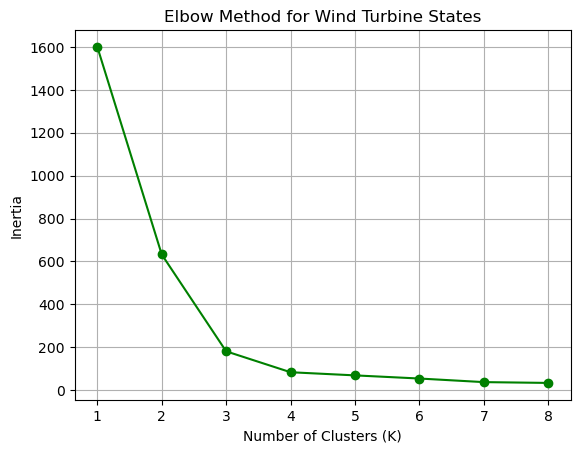

In [ ]:
import matplotlib.pyplot as plt

# Task 10: Plot range(1, 9) on the x-axis and your 'inertia_list' on the y-axis
# Use a line plot with markers (marker='o')
rng = range(1, 9)
plt.plot(rng, inertia_list, marker='o', color='green')

# Task 11: Add a title "Elbow Method for Wind Turbine States" and label the axes
plt.title("Elbow Method for Wind Turbine States")
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')

# Task 12: Show the plot. Visually identify the 'elbow' number.
plt.xticks(rng)  #To show every number in the range in plot.
plt.grid(True)
plt.show()
#Elbow is at K=4

e:\Miniforge_Conda\envs\internship\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


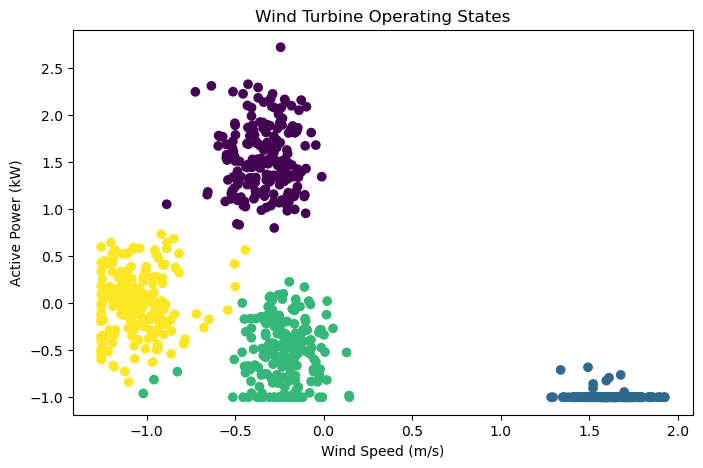

In [11]:
# Based on the elbow plot, you should see the elbow is at K=4.

# Task 13: Initialize a final KMeans model with n_clusters=4, random_state=42, and n_init='auto'
final_model = KMeans(n_clusters=4, random_state=42, n_init='auto')

# Task 14: Fit the model on 'X_scaled' AND generate cluster labels using the .fit_predict() method. 
# Save the output to a variable 'cluster_labels'
cluster_labels = final_model.fit_predict(X_scaled)

# Task 15: Create a scatter plot using 'Wind_Speed_ms' for X, 'Active_Power_kW' for Y. 
# Set the color parameter 'c' equal to 'cluster_labels' to color-code the states.
plt.figure(figsize=(8,5))
plt.scatter(X_scaled[:,0], X_scaled[:,1], c=cluster_labels)
plt.title('Wind Turbine Operating States')
plt.xlabel('Wind Speed (m/s)')
plt.ylabel('Active Power (kW)')
plt.show()